In [1]:
%load_ext autoreload
%autoreload 2

import utils
import sofm
import scov

In [2]:
from sklearn.metrics import adjusted_rand_score
import scov
import sofm 
import utils
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
ground_truth = pd.read_csv('~/Documents/SOFM/ground_truth_labels_151675.csv')
ground_truth = ground_truth['layer'].astype(str).values
labels, ground_truth = np.unique(ground_truth, return_inverse=True)

nan_idx = labels.shape[0]-1
genes = pd.read_csv('~/Documents/SOFM/gene_lookup.csv')
da = xr.open_dataset("~/Documents/SOFM/151675_spatial_expression.nc", engine='netcdf4')['logcounts']
da = da - da.mean(dim='spot')
da = da.rename({
    'gene': 'time', 
    'spot': 'location', 
    'array_col': 'lon', 
    'array_row': 'lat'
})

da = da.set_index(location=['lat', 'lon'])


In [4]:
int(da.shape[0]/9)

399

In [15]:
k = 7
mod = sofm.SOFM(da, k, nonstationary=True, max_lag = 100, block_sz=1, n_blocks=400)
#mod.spatcov_.plot_holdout()
mod.fit(lss = [3,5,7], rots = [0, np.pi/8, 2*np.pi/8])
sc = mod.spatcov_

[19:01:11] Estimating prior spatial covariance...


Validating length scales: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [03:49<00:00,  6.39s/it]


Fitting spline to the optimal length scales...
Latitudinal spline | Knots: 10 | gamma_u: 1.00e+03 | gamma_v: 1.39e+00
Longitudinal spline | Knots: 10 | gamma_u: 1.00e+03 | gamma_v: 5.18e+00
Rotational spline | Knots: 10 | gamma_u: 1.93e+01 | gamma_v: 7.20e+01
Refitting full model...
[19:05:46] Fit complete in 275.14 seconds.


In [16]:
sc = mod.spatcov_

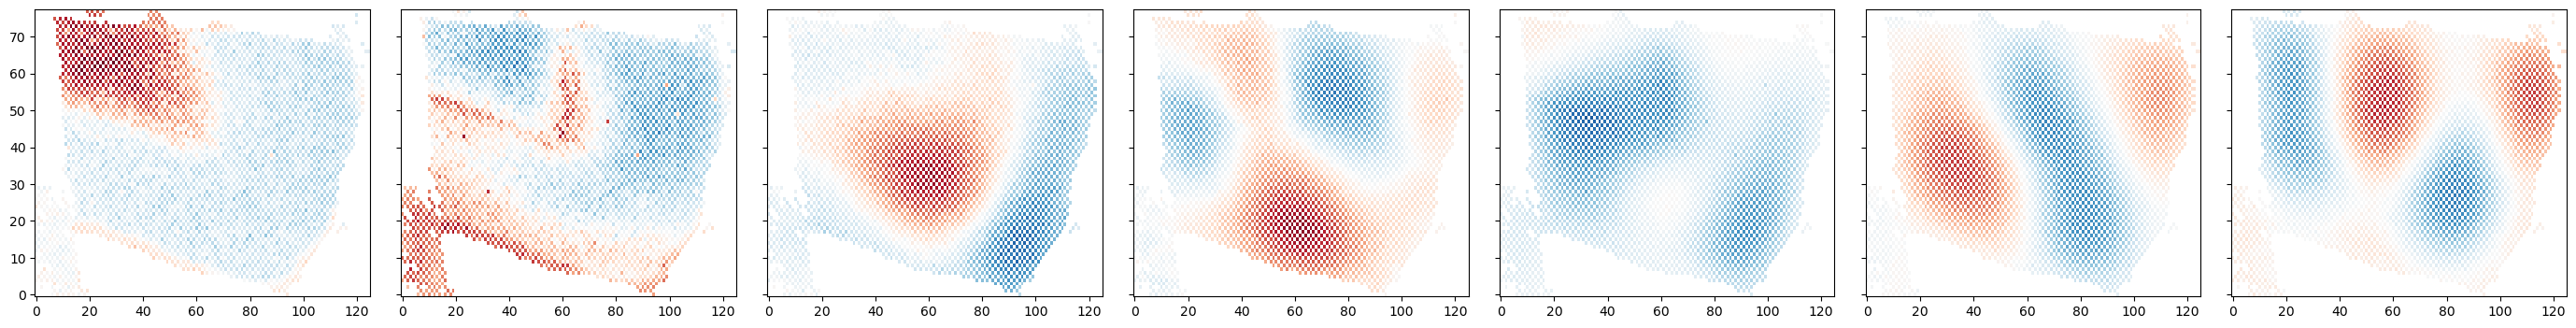

In [17]:
fig = mod.plot_loadings()

In [18]:
#fig.savefig('DLPFC_loadings_k7.png')

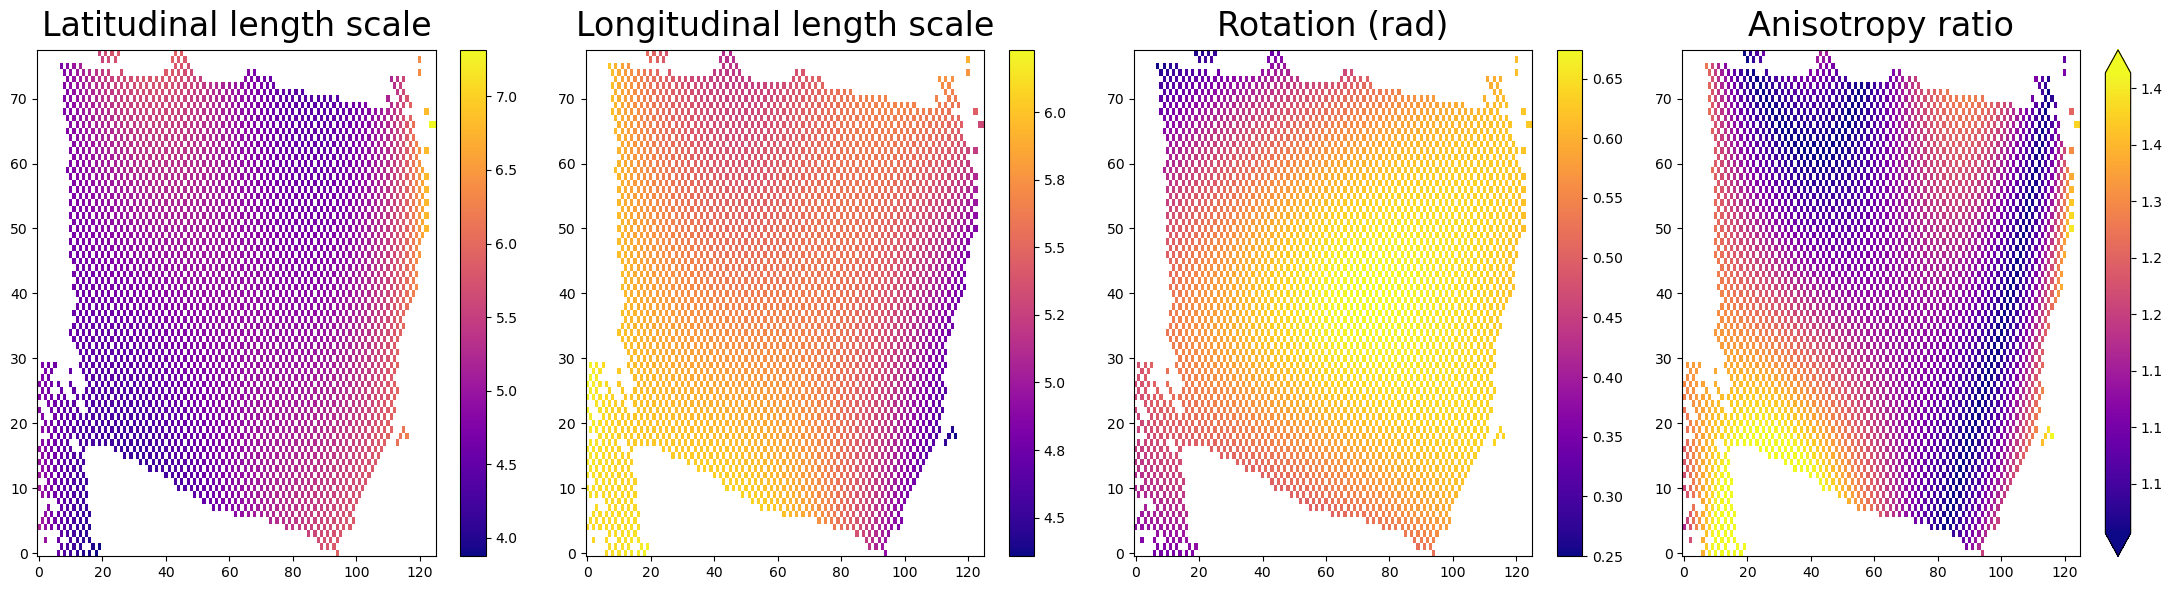

In [22]:
fig = sc.plot_nonstationary_spatcov()

In [20]:
#fig.savefig('DLPFC_nonstat_cov.png')

In [28]:
2*np.pi/8,np.pi/8, 3*np.pi/16

(0.7853981633974483, 0.39269908169872414, 0.5890486225480862)

In [33]:
import torch

In [34]:
genes = pd.read_csv('gene_lookup.csv')

In [35]:
EZ = mod.Ez_
U_est = mod.U_

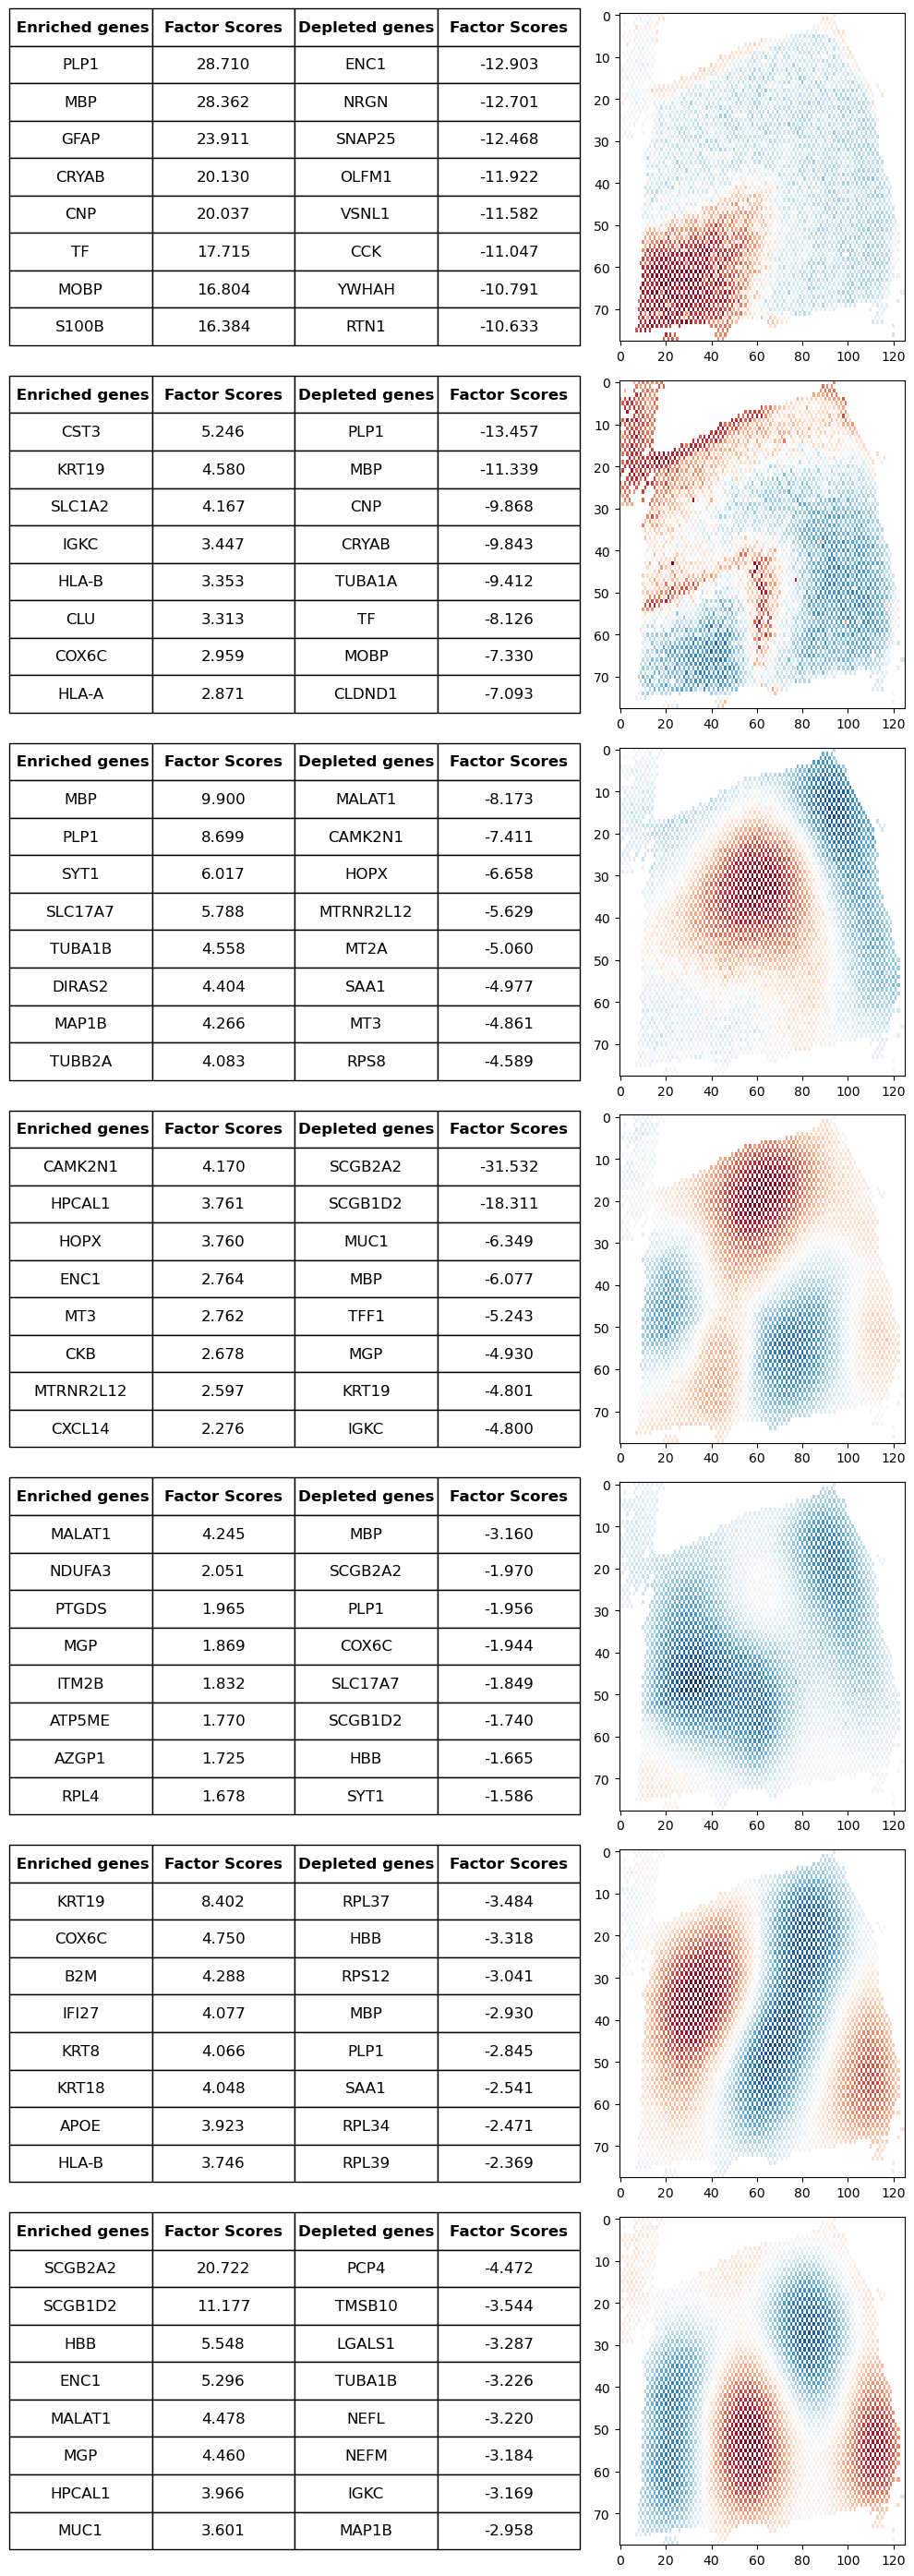

In [36]:
# 1. Map indices to gene symbols AND filter out MT- genes
# Create the full map first
full_gene_map = dict(zip(genes['index']-1, genes['gene_symbol']))

# Create a list of 'valid' indices (those that don't start with MT-)
valid_indices = [idx for idx, symbol in full_gene_map.items() if not str(symbol).startswith('MT-')]
valid_indices = torch.tensor(valid_indices)

# 2. Extract Top 10 Indices from the FILTERED subset
EZ_tensor = torch.tensor(EZ) if not isinstance(EZ, torch.Tensor) else EZ

# Filter the tensor to only include non-mitochondrial genes
filtered_EZ = EZ_tensor[:, valid_indices]

nu = 8
# Get topk from the filtered tensor
# Note: These indices refer to the position in 'filtered_EZ', not the original EZ_tensor
desc_v_raw, desc_i_raw = torch.topk(filtered_EZ, k=nu, dim=1, largest=True)
asc_v_raw, asc_i_raw = torch.topk(filtered_EZ, k=nu, dim=1, largest=False)

# Map those relative indices back to the original gene indices
descending_idx = valid_indices[desc_i_raw].numpy()
ascending_idx = valid_indices[asc_i_raw].numpy()

descending_vals = desc_v_raw.numpy()
ascending_vals = asc_v_raw.numpy()

# Use the full_gene_map for the rest of your plotting loop as gene_map
gene_map = full_gene_map

# 3. Setup Spatial DataArray
W_da = xr.DataArray(
    data=U_est,
    dims=('location', 'factor'),
    coords={
        'location': da.location,
        'factor': np.arange(k)
    }
)
W_da = W_da.set_index(location=['lat', 'lon']).unstack('location')
W_da = W_da.sortby(['lat', 'lon'])

# 4. Create Subplots (increased width to 20 to accommodate 4 columns)
fig, axes = plt.subplots(k, 2, figsize=(10, 4*k),gridspec_kw={'width_ratios': [2, 1]})

# Handle the edge case where k=1 (makes axes 1D instead of 2D)
if k == 1:
    axes = np.array([axes])

for j in range(k):
    # --- Left Panel (axes[j][0]): Table of Top Genes & Values ---
    
    # Retrieve the gene symbols and format the values for factor j
    desc_symbols = [gene_map.get(idx, str(idx)) for idx in descending_idx[j]]
    desc_v = [f"{val:.3f}" for val in descending_vals[j]]
    
    asc_symbols = [gene_map.get(idx, str(idx)) for idx in ascending_idx[j]]
    asc_v = [f"{val:.3f}" for val in ascending_vals[j]]
    
    # Combine into (10 rows, 4 columns) format required by matplotlib.table
    table_data = list(zip(desc_symbols, desc_v, asc_symbols, asc_v))
    
    ax_table = axes[j][0]
    ax_table.axis('tight')
    ax_table.axis('off') # Hide the standard plot axes
    
    # Draw the table with 4 columns
    table = ax_table.table(
        cellText=table_data,
        colLabels=[' Enriched genes', 'Factor Scores', 'Depleted genes', 'Factor Scores'],
        loc='center',
        cellLoc='center'
    )
    
    # Styling the table for readability
    table.scale(1, 1.8) # Increase row height slightly
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    
    # Bold the column headers
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')

    # --- Right Panel (axes[j][1]): Spatial Loadings Plot ---
    ax_plot = axes[j][1]
    (1*W_da).isel(factor=j).plot(ax=ax_plot, cmap='RdBu_r', add_colorbar=False)
    ax_plot.set_title('')#(f'Factor {j} Spatial Loadings', fontweight='bold')
    ax_plot.set_xlabel('')
    ax_plot.set_ylabel('')
    ax_plot.invert_yaxis()

plt.tight_layout()
plt.savefig('151675_gene_map_SOFM.png')
plt.show()

In [55]:
U_est = mod.U_
L = mod.L_
U_weighted = U_est*L.detach().unsqueeze(0)

W_da = xr.DataArray(
    data=U_weighted,
    dims=('location', 'factor'),
    coords={
        'location': da.location,
        'lat': da['lat'],
        'lon': da['lon'],
        'factor': np.arange(k)
    }
)

label_pred = W_da.argmax(dim='factor').values
ari_score = adjusted_rand_score(ground_truth[ground_truth!=nan_idx], label_pred[ground_truth!=nan_idx])
print(f"Adjusted Rand Index: {ari_score:.3f}")

np.savetxt('./U_weighted.csv', U_weighted, delimiter=',')
np.savetxt('./U_unweighted.csv', U_est, delimiter=',')
np.savetxt('./U_weighted_sq.csv', U_weighted*L.detach().unsqueeze(0), delimiter=',')

Adjusted Rand Index: 0.324


In [101]:
U_stacked = np.column_stack([U_weighted.numpy(),sc.lam_lat_,sc.lam_lon_,sc.rot_])
np.savetxt('./U_stacked.csv', U_stacked, delimiter=',')